# Hackathon 2 — Pipeline Completo

**Duração: 1h30. Trabalho em trio.**

## Contexto

Um distribuidor atacadista vende produtos para dois tipos de clientes: estabelecimentos do ramo **Horeca** (hotéis, restaurantes, cafés) e clientes do canal **Retail** (varejo). Essa informação de canal é importante para decisões comerciais (política de preços, frequência de entrega, equipe de vendas dedicada), mas o cadastro de uma parte da base está incompleto, o campo de canal não foi preenchido para novos clientes.

Você recebeu o histórico de gastos anuais de 440 clientes em 6 categorias de produto. Para os clientes com canal conhecido, o objetivo é descobrir **o que diferencia o padrão de consumo de cada canal**, e usar isso para construir um modelo que preveja o canal de clientes novos.

## Objetivo

Construir um pipeline que combine duas etapas:

1. **Uma técnica não-supervisionada** (PCA **ou** clustering) aplicada aos dados de gasto, usada como preparação ou insumo de feature para a etapa seguinte.
2. **Um modelo supervisionado** que preveja `Channel` (Horeca ou Retail) a partir dos dados.

Não existe "a resposta certa" entre PCA e clustering, mas existe o caminho que seu trio conseguir justificar melhor.

## Regras

- Escolham **uma** técnica não-supervisionada: PCA (redução de dimensionalidade) **ou** clustering (ex.: K-Means). Não é necessário fazer as duas.
- Treinem **um único modelo supervisionado** final, não é necessário comparar vários algoritmos desta vez.
- Pode usar qualquer algoritmo visto no Módulo 3 ou técnica do Módulo 5.
- O dataset já está na pasta `data/` deste repositório — não depende de internet.
- O dataset já veio com os outliers mais extremos tratados — não é necessário caçar outliers desta vez. O foco é a combinação das duas etapas do pipeline.
- **REGRA MAIS IMPORTANTE**: não deixe a IA fazer tudo, senão você não aprenderá nada :)

## O dataset

Arquivo: `data/wholesale_customers.csv`, 440 clientes, 7 colunas.

| Coluna | Descrição |
|---|---|
| `Channel` | **variável-alvo** — 1 = Horeca, 2 = Retail |
| `Fresh` | gasto anual com produtos frescos |
| `Milk` | gasto anual com laticínios |
| `Grocery` | gasto anual com mercearia |
| `Frozen` | gasto anual com congelados |
| `Detergents_Paper` | gasto anual com produtos de limpeza e papel |
| `Delicatessen` | gasto anual com produtos de delicatessen |

**Observação:** as colunas de gasto estão em escalas bem diferentes entre si, e algumas são claramente correlacionadas. Isso é relevante tanto para a escolha da técnica não-supervisionada quanto para o pré-processamento antes do modelo.

## Por onde começar (sugestão, não obrigatório)

Com 90 minutos, um caminho possível:

1. **10 min** — carregar os dados, dar uma olhada geral (`.describe()`, `.corr()`, distribuição de `Channel`).
2. **15 min** — decidir entre PCA e clustering, e justificar a escolha em uma frase (ela vai pro resumo final).
3. **25-30 min** — aplicar a técnica escolhida.
4. **20-25 min** — usar o resultado (componentes do PCA, ou o cluster como feature) para treinar o modelo supervisionado que prevê `Channel`.
5. **10 min finais** — avaliar o modelo, revisar o notebook do início ao fim, escrever a síntese final.

---
## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score

# pode incluir outras bibliotecas conforme necessário

pd.set_option('display.max_columns', None)


## 1. Carregar e explorar os dados

In [3]:
df = pd.read_csv('data/wholesale_customers.csv')
df.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,2,12669.0,9656.0,7561.0,214.0,2674.0,1338.0
1,2,7057.0,9810.0,9568.0,1762.0,3293.0,1776.0
2,2,6353.0,8808.0,7684.0,2405.0,3516.0,7844.0
3,1,13265.0,1196.0,4221.0,6404.0,507.0,1788.0
4,2,22615.0,5410.0,7198.0,3915.0,1777.0,5185.0


In [4]:
df.describe()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,11797.643295,5641.214318,7715.149318,2891.643409,2787.916023,1387.448409
std,0.468052,11556.065072,6382.145852,8103.786401,3537.152169,4203.651451,1470.885271
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,56082.610000,37610.060000,43435.740000,17964.820000,22571.610000,8274.660000


In [5]:
df['Channel'].value_counts(normalize=True)

Channel
1    0.677273
2    0.322727
Name: proportion, dtype: float64

In [6]:
# Vale olhar a correlação entre as colunas de gasto antes de decidir
# entre PCA e clustering.
df.drop(columns=['Channel']).corr()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Fresh,1.000000,0.052198,-0.051910,0.381219,-0.136264,0.278835
Milk,0.052198,1.000000,0.767125,0.072928,0.691414,0.448538
Grocery,-0.051910,0.767125,1.000000,-0.086003,0.903659,0.303369
Frozen,0.381219,0.072928,-0.086003,1.000000,-0.167969,0.277966
Detergents_Paper,-0.136264,0.691414,0.903659,-0.167969,1.000000,0.171181
Delicatessen,0.278835,0.448538,0.303369,0.277966,0.171181,1.000000


**Pare e pensem:** olhando a correlação acima e a pergunta de negócio (descobrir o que diferencia os padrões de consumo), qual das duas técnicas faz mais sentido aqui, reduzir a dimensionalidade das colunas de gasto, ou segmentar os clientes em grupos? Não precisa ser uma escolha complicada, só precisa ser justificável.

## 2. Pré-processamento

In [7]:
# As colunas de gasto estão em escalas bem diferentes.
# Pensem se e onde a padronização (StandardScaler) é necessária antes da próxima etapa.

features_gasto = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen']

total_gasto = df[features_gasto].sum(axis=1)

df_proporcional = df[features_gasto].div(total_gasto, axis=0)
df_proporcional['Total'] = total_gasto

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_proporcional)
df_scaled = pd.DataFrame(X_scaled, columns=df_proporcional.columns)


df_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total
0,-0.017908,1.024209,-0.056877,-0.896136,0.051372,-0.190695,0.085548
1,-0.663372,1.129460,0.396792,-0.472120,0.307742,0.153115,0.047275
2,-0.819845,0.646230,-0.137780,-0.356562,0.271023,4.057975,0.198556
3,0.440348,-1.105938,-0.521036,1.170763,-0.693707,0.442281,-0.218961
4,0.465087,-0.450366,-0.507414,-0.181923,-0.444442,1.587305,0.627881


## 3. Etapa não-supervisionada (escolham PCA OU clustering)

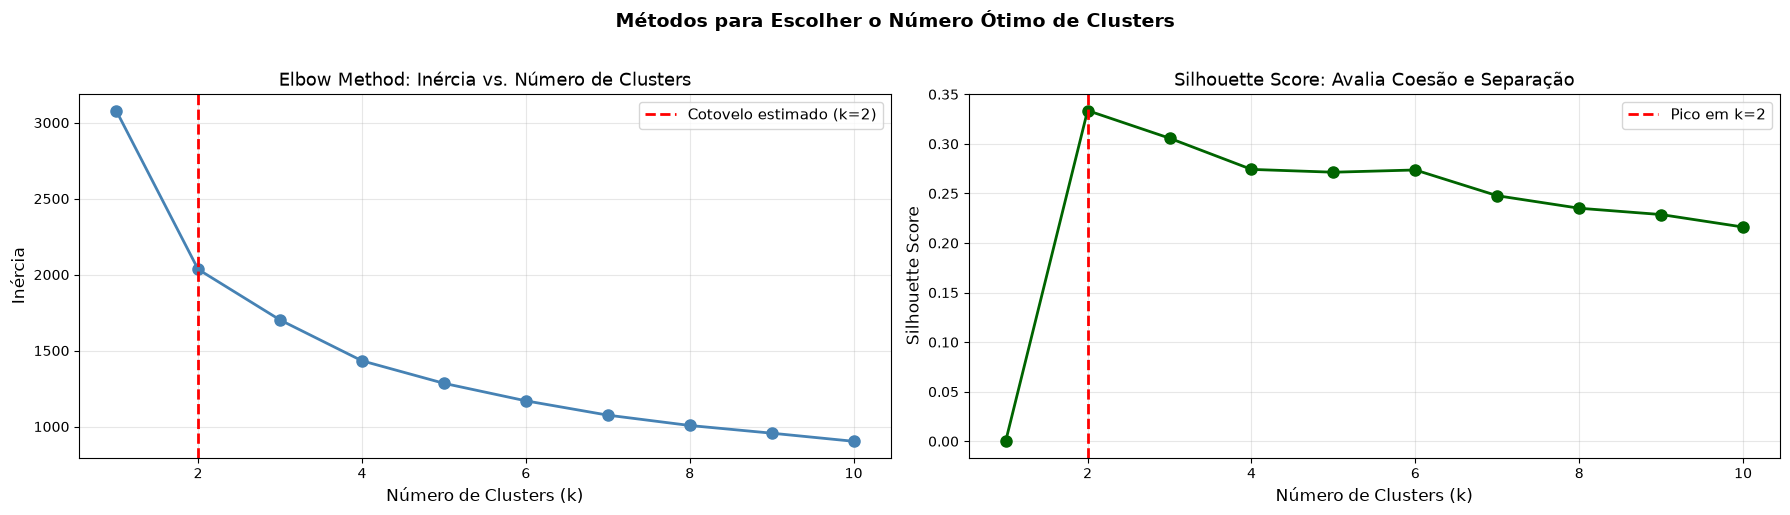

In [28]:
# Calcular inércia para diferentes valores de k
k_range = range(1, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score (apenas para k > 1)
    if k > 1:
        sil_score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(sil_score)
    else:
        silhouette_scores.append(0)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].axvline(x=2, color='red', linestyle='--', linewidth=2, label='Cotovelo estimado (k=2)')
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inércia', fontsize=12)
axes[0].set_title('Elbow Method: Inércia vs. Número de Clusters', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1].axvline(x=2, color='red', linestyle='--', linewidth=2, label='Pico em k=2')
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score: Avalia Coesão e Separação', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Métodos para Escolher o Número Ótimo de Clusters', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()
    

In [ ]:
# K-Means com k=2 (ou k=4) e avaliação não-supervisionada
kmeans_optimal = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_optimal = kmeans_optimal.fit_predict(df_scaled)
df_scaled["cluster"] = labels_optimal

# Calcular métricas não-supervisionadas
features_only = df_scaled.drop(columns=["cluster"])
sil_score = silhouette_score(features_only, labels_optimal)
db_index = davies_bouldin_score(features_only, labels_optimal)
ch_score = calinski_harabasz_score(features_only, labels_optimal)

print("Avaliação dos Clusters (K-Means):")
print(f"  Silhouette Score: {sil_score:.4f} (range: -1 a 1, maior é melhor)")
print(f"  Davies-Bouldin Index: {db_index:.4f} (menor é melhor)")
print(f"  Calinski-Harabasz Score: {ch_score:.4f} (maior é melhor)")


## 4. Modelo supervisionado

In [ ]:
# Usem o resultado da etapa anterior (componentes do PCA, ou a coluna de cluster
# somada às features originais) para treinar um único modelo que preveja Channel.
# X = ...
# y = ...
# X_train, X_test, y_train, y_test = train_test_split(...)
from sklearn.linear_model import LogisticRegression

X = df_scaled
y = df['Channel']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


modelo = LogisticRegression(class_weight='balanced', random_state=42)
modelo.fit(X_train, y_train)
    

y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Horeca (1)', 'Retail (2)']))



              precision    recall  f1-score   support

  Horeca (1)       0.92      0.91      0.91        75
  Retail (2)       0.81      0.83      0.82        35

    accuracy                           0.88       110
   macro avg       0.86      0.87      0.86       110
weighted avg       0.88      0.88      0.88       110



## 5. Avaliação

In [ ]:
# Avaliem o modelo com uma métrica apropriada ao desbalanceamento
# (Channel tem cerca de 68% / 32% de distribuição entre as classes).


---
## Síntese final (preencham antes de encerrar)

**Técnica não-supervisionada escolhida e por quê:**

Escolhemos o método de agrupamento por kmeans mesmo os dados sendo correlacionados, porque o dataframe utilizado tem apenas 6 features, oque é relativamente pouco para um PCA

**Modelo supervisionado usado:**

**Métrica escolhida e valor obtido:**

**Se tivessem mais tempo, o que tentariam a seguir:**